In [1]:
%load_ext kedro.ipython
import pandas as pd
pd.set_option('display.max_colwidth', 1000)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import altair as alt
alt.data_transformers.enable("vegafusion")

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

[11/06/24 15:58:58] INFO     Registered line magic '%reload_kedro'                                   ]8;id=385051;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=266220;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#58\58]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=203455;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=558850;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#60\60]8;;\

                    INFO     Resolved project path as: /home/dampudia/projects/dsit-impact.         ]8;id=325784;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=886935;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#171\171]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

[11/06/24 15:58:59] WARNING  /home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedr ]8;id=940506;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=865366;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/warnings.py#110\110]8;;\
                             o_viz/__init__.py:13: KedroVizPythonVersionWarning: Please be advised                 
                             that Kedro Viz is not yet fully                                                       
                                     compatible with the Python version you are currently using.                   
                               warnings.warn(                                                                      
                                                                                                                   

                    INFO     Kedro project dsit-impact                                              ]8;id=479267;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=976496;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#141\141]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=352219;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=315029;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#142\142]8;;\
                             'pipelines'                                                                           

[11/06/24 15:59:00] INFO     Registered line magic 'run_viz'                                        ]8;id=982977;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=820879;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#148\148]8;;\

# Deep Dive into Impact and Team Science Metrics

### Introduction

This notebook explores the **impact and team science metrics** developed as part of the collaboration between IGL and DSIT to evaluate the interdisciplinary influence and collaborative structure of UKRI-funded research publications. The approach leverages data from GtR and bibliometric and contextual data collected from OpenAlex, CrossRef, and Semantic Scholar.

The project involved several key stages:
1. **DOI Labelling and Dataset Matching**: For GtR publications without DOIs, IGL combined metadata searches on CrossRef and OpenAlex with cosine similarity checks to identify and link publications accurately. Previous sessions described the steps and assumptions taken through the relevant pipelines.
2. **Citation Context and Intent**: By leveraging data from Semantic Scholar and open-access full texts, IGL enriched citation data with contextual information, allowing us to classify citations by purpose (e.g., methodology, results).
3. **Diversity and Team Metrics**: IGL measured the diversity within research teams and topics by quantifying the balance, variety, and disparity of the disciplines involved.

In [2]:
gtr_publications = catalog.load("oa.publications.gtr.primary")

[11/06/24 15:59:01] INFO     Loading data from oa.publications.gtr.primary (ParquetDataset)...  ]8;id=479490;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=150783;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py#508\508]8;;\

In [3]:
gtr_publications.loc[gtr_publications["id"]=="W1963651550"]

,id,title,authorships,doi
57513,W1963651550,The Timing of Developmental Transitions in Plants,"[[A5021738968, I100288624, GB, first], [A5074175217, I100288624, GB, last]]",https://doi.org/10.1016/j.cell.2006.05.005



This notebook focuses on the development of the two sets of metrics to assess impact and interdisciplinarity: **Citation Metrics** and **Diversity Metrics**.

## Citation Metrics

The first set of metrics centers on the citation patterns and influence of GtR-linked publications. This process involved two primary data sources: **Semantic Scholar** and **open-access PDFs**. From Semantic Scholar, we gathered citation counts alongside contextual citation sentences. For each citation, we identified **citation intent** (e.g., citing the paper for its methodology, background, or results) and captured **influential citation counts**, a measure of citations that have made a notable impact in their respective fields. 

In [4]:
citation_details_dict = catalog.load("s2.citation_details.raw")
example_citation_details = citation_details_dict["s0"]()

[11/06/24 15:59:38] INFO     Loading data from s2.citation_details.raw (PartitionedDataset)...  ]8;id=195673;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=950869;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py#508\508]8;;\

In [20]:
example_citation_details.loc[(example_citation_details["id"]=="W1963651550")&(example_citation_details["is_open_access"])]

,id,pmid,doi,mag_id,is_open_access,pdf_url,influential,intent,context
244673,W1963651550,38605371,10.1186/s12870-024-04916-w,,True,https://bmcplantbiol.biomedcentral.com/counter/pdf/10.1186/s12870-024-04916-w,False,background,"…experience major transitions during its lifecycle [46–49], including the transition from the juvenile to adult phase during vegetative development [50–52], the flowering transition from vegetative to reproductive development [50, 51, 53, 54], and senescence in late reproductive phase [55–58]."
244674,W1963651550,38417841,10.1093/plphys/kiae109,,True,https://academic.oup.com/plphys/advance-article-pdf/doi/10.1093/plphys/kiae109/56793021/kiae109.pdf,False,background,"This competence is thought to be associated with the transition from juvenile to adult vegetative phase; however, this is not true for all species (Poethig 2003; Baurle and Dean 2006; Hyun et al. 2017; Poethig and Fouracre 2024)."
244675,W1963651550,38410737,10.3389/fpls.2024.1336892,,True,https://www.frontiersin.org/journals/plant-science/articles/10.3389/fpls.2024.1336892/pdf,False,background,"In annuals, ﬂ ower initiation begins with the transition from vegetative to in ﬂ orescence stage and ﬂ ower formation and development are typically completed within a single season (see reviews by Baurle and Dean, 2006; Irish, 2010)."
244676,W1963651550,38262939,10.1186/s12864-024-09995-5,,True,https://bmcgenomics.biomedcentral.com/counter/pdf/10.1186/s12864-024-09995-5,False,background,"The SPL gene is widely involved in plant growth and development and plays a vital role in promoting the transition of plants from the seedling stage to the mature stage [56, 57]."
244677,W1963651550,38179836,10.1093/pcp/pcae001,,True,https://academic.oup.com/pcp/advance-article-pdf/doi/10.1093/pcp/pcae001/55040283/pcae001.pdf,False,background,"1 ) (B ̈ aurle and Dean 2006, Huijser and Schmid 2011, Kyozuka et al. 2014)."
...,...,...,...,...,...,...,...,...,...
245216,W1963651550,18798874,10.1111/j.1365-313X.2008.03684.x,1980219201,True,https://onlinelibrary.wiley.com/doi/pdfdirect/10.1111/j.1365-313X.2008.03684.x,False,background,"Both the autonomous (developmental) and vernalization pathways act to repress FLC expression to induce flowering (Baurle and Dean, 2006)."
245218,W1963651550,19436046,10.1093/jxb/erp142,,True,https://academic.oup.com/jxb/article-pdf/60/11/3143/1419558/erp142.pdf,False,background,"Growing knowledge on the genetics and the physiology of the onset of flowering (Bernier and Périlleux, 2005; Anthony, 2006; Bäurle and Dean, 2006; Roux et al., 2006; Glover, 2007) opens up new possibilities in the field of evolutionary ecology, or in understanding how genes vary in heterogeneous and/or changing environments and how natural selection acts on this variation."
245219,W1963651550,19436046,10.1093/jxb/erp142,,True,https://academic.oup.com/jxb/article-pdf/60/11/3143/1419558/erp142.pdf,False,background,"Growing knowledge on the genetics and the physiology of the onset of flowering (Bernier and Périlleux, 2005; Anthony, 2006; Bäurle and Dean, 2006; Roux et al., 2006; Glover, 2007) opens up new possibilities in the field of evolutionary ecology, or in understanding how genes vary in heterogeneous…"
245237,W1963651550,17381293,10.1101/SQB.2006.71.030,2121821954,True,http://symposium.cshlp.org/content/71/165.full.pdf,False,background,"Like all flowering plants, Arabidopsis undergoes a transition from a juvenile to an adult phase of vegetative devel-\nopment prior to flowering (Brink 1962; Telfer et al. 1997; Kerstetter and Poethig 1998; Baurle and Dean 2006)."


To enhance the contextual information, we scraped open-access PDFs for additional citation mentions. We matched citations to a set of predefined headers (e.g., “Introduction,” “Methods,” “Results”) to categorise citation context within the structure of citing papers.

In [6]:
pdf_details = catalog.load("pdfs.section_shares.intermediate")

[11/06/24 15:59:46] INFO     Loading data from pdfs.section_shares.intermediate                 ]8;id=977100;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=365854;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py#508\508]8;;\
                             (ParquetDataset)...                                                                   

In [7]:
pdf_details.loc[pdf_details["parent_id"]=="W1963651550"].iloc[0]


main_section_heading
parent_id                W1963651550
Abstract                         0.0
Background                       8.0
Conclusion                       0.0
Data Analysis                    0.0
Data Collection                  0.0
Discussion                      13.0
Empirical Design                 0.0
Error                            5.0
Experimental Design              0.0
Introduction                    27.0
Limitations                      0.0
Methods                          1.0
Not Found                        1.0
Results                          6.0
total_sections                  61.0
unique_dois                       56
Methodology                      0.0
Acknowledgements                 0.0
Data                             0.0
Literature Review                0.0
Theoretical Framework            0.0
Recommendations                  0.0
Future Work                      0.0
Name: 12692, dtype: object

## Diversity Metrics

The second set of metrics explores the **diversity of research topics and team composition** within GtR publications. Using either taxonomy labels from the GtR publications, or by collecting labels across all publications by GtR-affiliated authors (dating back to 2007), we built a foundation to analyse interdisciplinary work.

To quantify diversity, we applied a modified version of the **DIV function** proposed by Leydesdorff and expanded by Rousseau. This function captures three dimensions of diversity.

### 1. Variety ($ \frac{nc}{N} $)

**Variety** represents the breadth of unique disciplines or topics involved in a research paper or team. In the context of team science, high variety suggests contributions from a wide range of fields. 

$$
\text{Variety} = \frac{nc}{N}
$$

where:
- $ nc $: The number of unique disciplines or topics present.
- $ N $: The total possible number of disciplines in the dataset.

This component captures how many distinct fields are involved, with higher values indicating greater diversity of expertise or research themes.

### 2. Evenness ($ 1 - \text{Gini} $)

**Evenness** reflects the balance of contributions from each discipline, highlighting how evenly the topics or disciplinary inputs are distributed across the research. A perfectly balanced paper or team would have equal representation across all fields, while an imbalance indicates that certain disciplines dominate the work. 

$$
\text{Evenness} = 1 - \text{Gini}
$$

where:
- **Gini coefficient**: A statistical measure of distribution inequality, ranging from 0 (perfect balance) to 1 (perfect inequality). By taking $ 1 - \text{Gini} $, we ensure that values closer to 1 indicate a more balanced distribution.

### 3. Disparity ($ \frac{\sum dij}{nc \times (nc - 1)} $)

**Disparity** measures the distinctiveness or **dissimilarity** between disciplines within a research team or paper. This dimension captures the extent to which the included fields differ from one another, as more distinct fields can contribute to a more interdisciplinary output.

$$
\text{Disparity} = \frac{\sum dij}{nc \times (nc - 1)}
$$

where:
- $ dij $: The distance or dissimilarity between disciplines $ i $ and $ j $, typically sourced from a disparity matrix that quantifies the “distance” between different fields.
- $ nc $: The number of unique disciplines represented in the research.



The product of these three dimensions is the **DIV function**:

$$
\text{DIV} = \left(\frac{nc}{N}\right) \times (1 - \text{Gini}) \times \frac{\sum dij}{nc \times (nc - 1)}
$$

This function captures the comprehensive diversity of research teams or topics by balancing the range, equality, and distinctiveness of disciplines.

In [9]:
author_field_scores = catalog.load("publications.field.coauthor_diversity_scores.intermediate")

[11/06/24 15:59:47] INFO     Loading data from                                                  ]8;id=158577;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=380250;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py#508\508]8;;\
                             publications.field.coauthor_diversity_scores.intermediate                             
                             (ParquetDataset)...                                                                   

In [10]:
author_field_scores.head(2)

,id,variety,evenness,disparity
0,W100026782,0.076923,1.000000,0.562595
1,W1000799695,0.192308,0.179825,0.551278


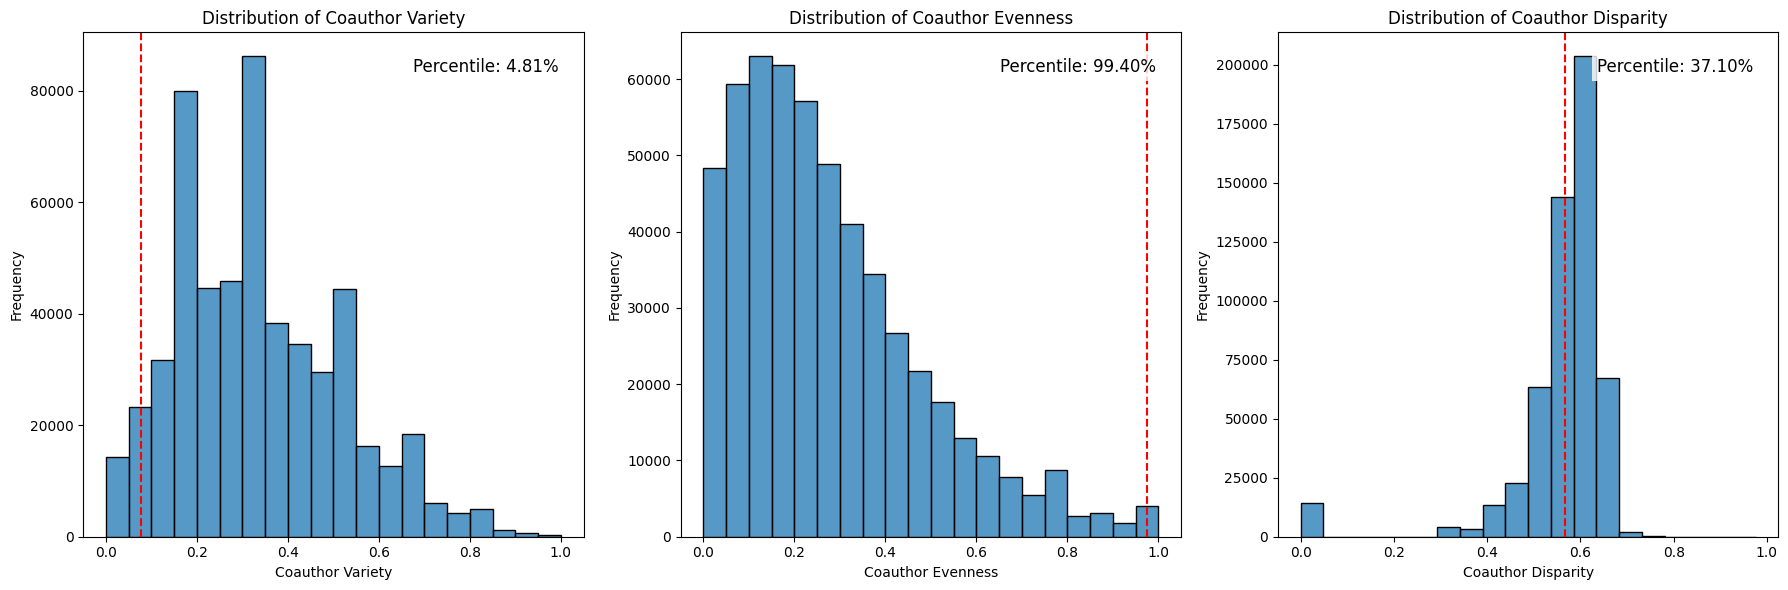

In [11]:
from scipy.stats import percentileofscore
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

reference_paper = author_field_scores.loc[author_field_scores["id"] == "W1963651550"]

# Plot variety, evenness, and disparity
for i, metric in enumerate(["variety", "evenness", "disparity"]):
    sns.histplot(author_field_scores[metric], bins=20, kde=False, ax=axes[i])
    axes[i].axvline(
        reference_paper[metric].values[0],
        color="red",
        linestyle="--",
        label="Reference Paper",
    )
    axes[i].set_title(f"Distribution of Coauthor {metric.capitalize()}")
    axes[i].set_xlabel(f"Coauthor {metric.capitalize()}")
    axes[i].set_ylabel("Frequency")
    percentile = percentileofscore(author_field_scores[metric], reference_paper[metric].values[0])
    axes[i].text(
        0.95, 0.95,
        f"Percentile: {percentile:.2f}%",
        transform=axes[i].transAxes,
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
    )

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

## Final data

In [12]:
final_data = catalog.load("oa.publications.gtr.base.data")

[11/06/24 15:59:50] INFO     Loading data from oa.publications.gtr.base.data                    ]8;id=435352;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=63480;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py#508\508]8;;\
                             (ParquetDataset)...                                                                   

In [13]:
final_data.loc[final_data["id"]=="W1963651550"]

,id,doi,pmid,mag_id,title,publication_date,cited_by_count,counts_by_year,authorships,topics,...,open_access_count,total_sections,section_counts,coauthor_variety,coauthor_evenness,coauthor_disparity,paper_variety,paper_evenness,paper_disparity,outcome_id
56024,W1963651550,https://doi.org/10.1016/j.cell.2006.05.005,16713560,1963651550,The Timing of Developmental Transitions in Plants,2006-05-01,601,"[[2024, 30], [2023, 27], [2022, 34], [2021, 28], [2020, 34], [2019, 28], [2018, 25], [2017, 28], [2016, 32], [2015, 31], [2014, 26], [2013, 33], [2012, 45]]","[[A5021738968, I100288624, GB, first], [A5074175217, I100288624, GB, last]]","[[T10184, Molecular Mechanisms of Plant Development and Regulation, subfields/1110, Plant Science, fields/11, Agricultural and Biological Sciences, domains/1, Life Sciences], [T11927, Molecular Mechanisms of Pollen Development and Function, subfields/1312, Molecular Biology, fields/13, Biochemistry, Genetics and Molecular Biology, domains/1, Life Sciences], [T11268, Light Signal Transduction in Plants, subfields/1110, Plant Science, fields/11, Agricultural and Biological Sciences, domains/1, Life Sciences]]",...,173,61,"[[Background, 8], [Discussion, 13], [Error, 5], [Introduction, 27], [Methods, 1], [Not Found, 1], [Results, 6]]",0.076923,0.97561,0.567742,0.076923,0.8,0.567742,[1A563FD4-C280-4163-B599-B432D123F3D6]
